/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
100%|██████████| 12000/12000 [00:00<00:00, 220139.73it/s]


Visualizing sample 0


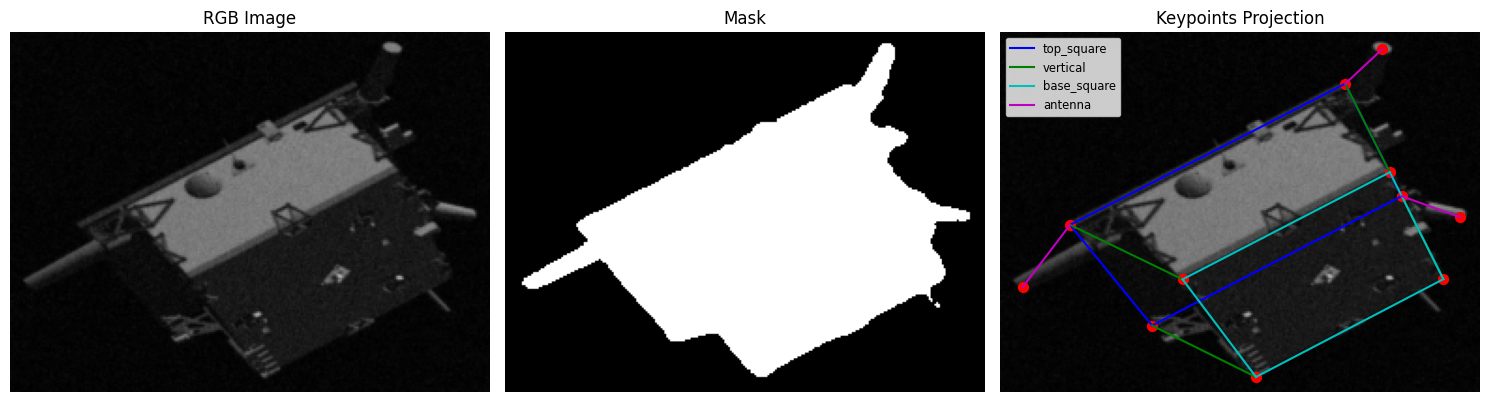

Visualizing sample 1


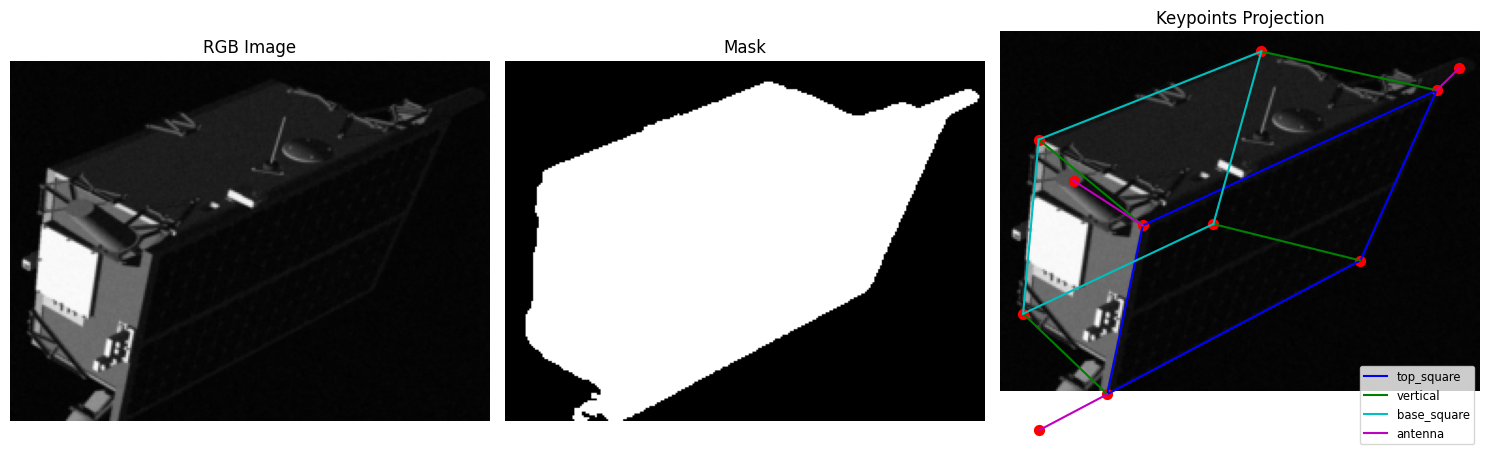

Visualizing sample 2


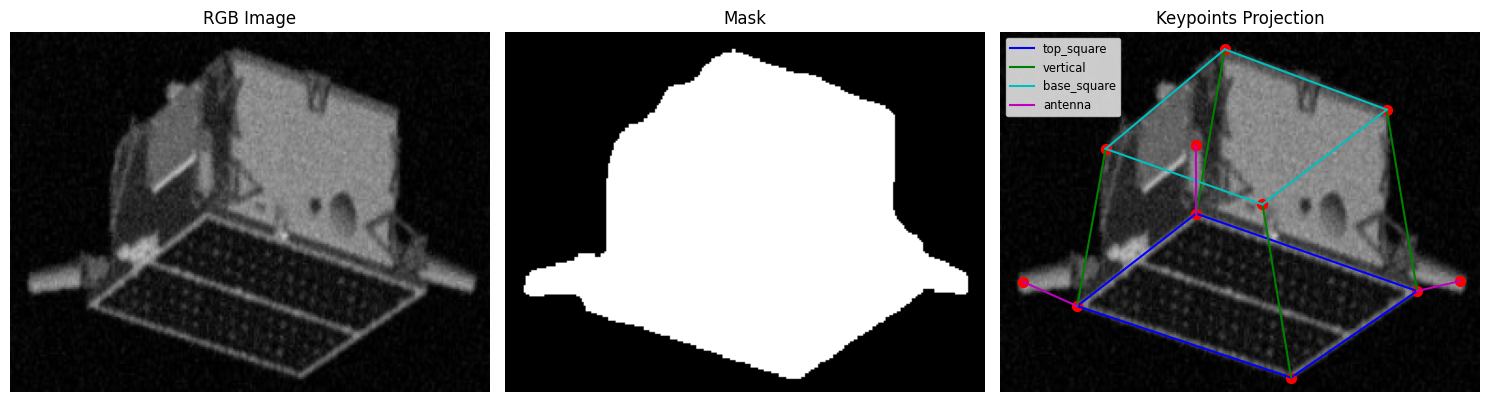

Visualizing sample 3


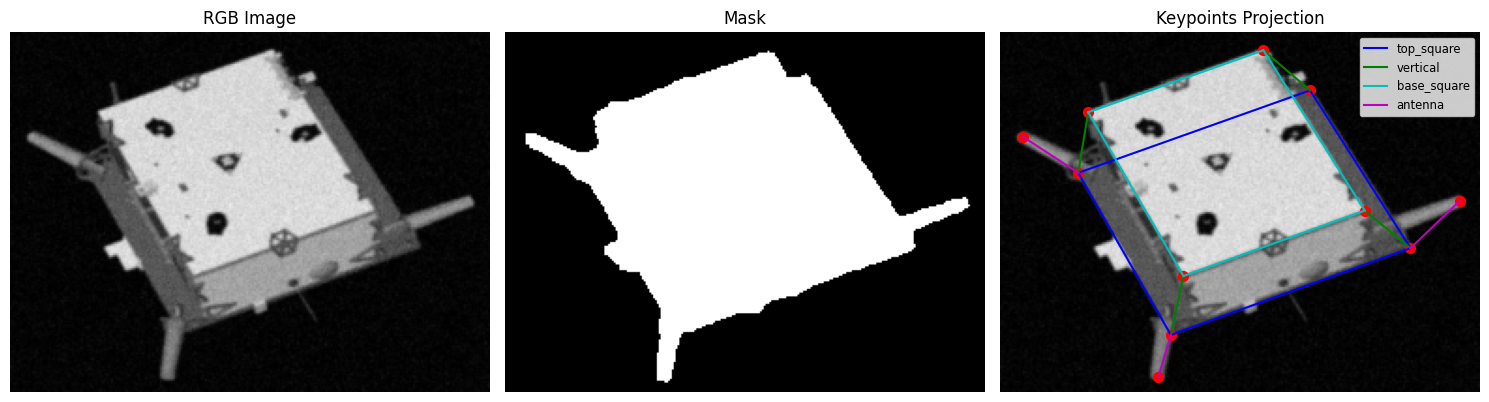

Visualizing sample 4


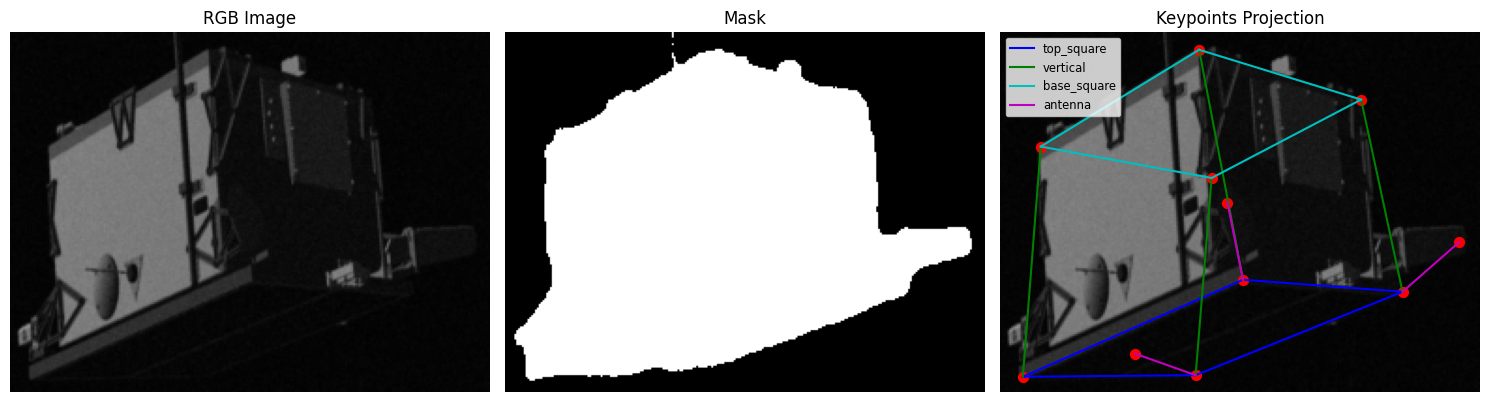

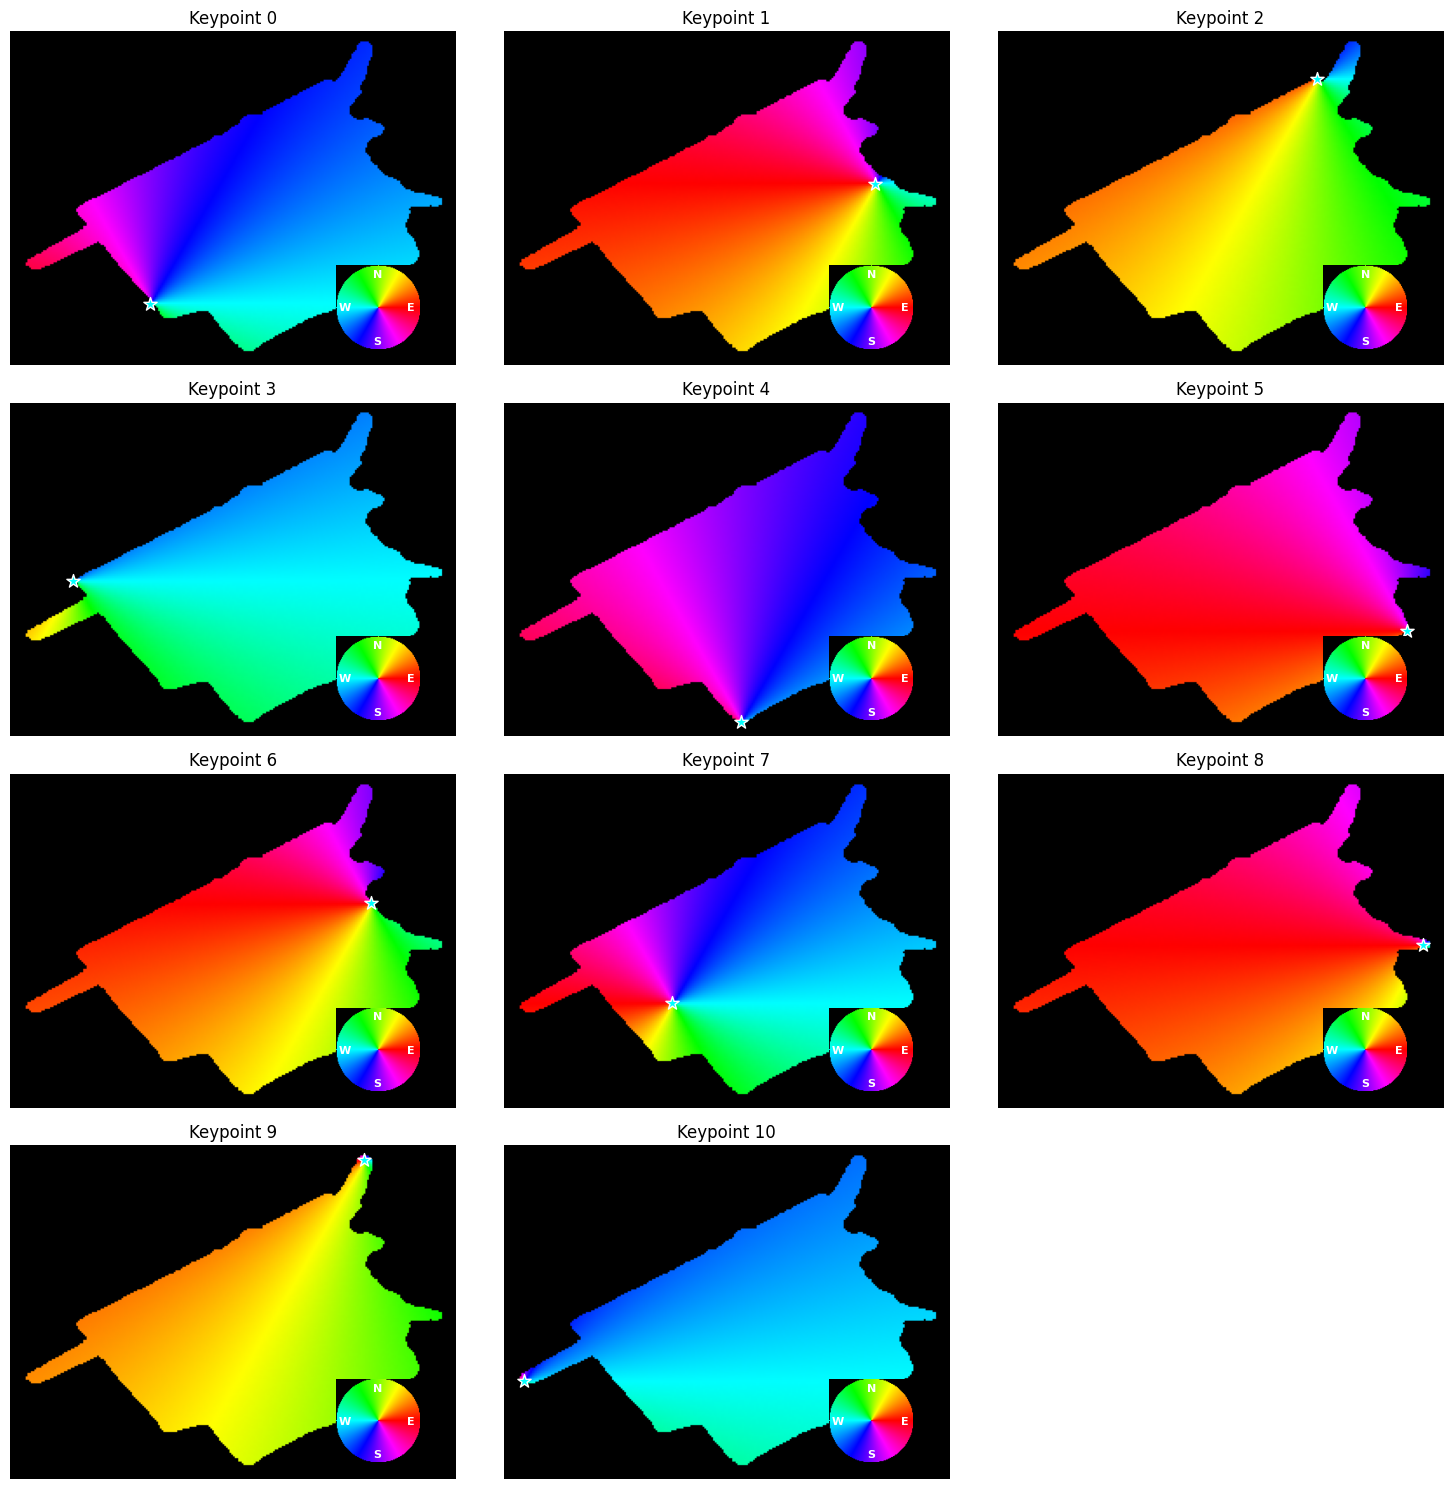

/tmp/ipykernel_19/2144815962.py:1264: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epoch 1 

/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


Epoch 1 : Training loss: 0.094165 - Validation loss: 0.062327                                         
Epoch 2 : Training loss: 0.093024 - Validation loss: 0.060274                                         
Epoch 3 : Training loss: 0.090009 - Validation loss: 0.060835                                         
Epoch 4 : Training loss: 0.088802 - Validation loss: 0.058887                                         
Epoch 5 : Training loss: 0.088324 - Validation loss: 0.058638                                         
Epoch 6 : Training loss: 0.087218 - Validation loss: 0.057390                                         
Epoch 7 : Training loss: 0.086204 - Validation loss: 0.058807                                         
Epoch 8 : Training loss: 0.086778 - Validation loss: 0.062479                                         
Epoch 9 : Training loss: 0.087681 - Validation loss: 0.060659                                         
Epoch 10 : Training loss: 0.086921 - Validation loss: 0.059176           

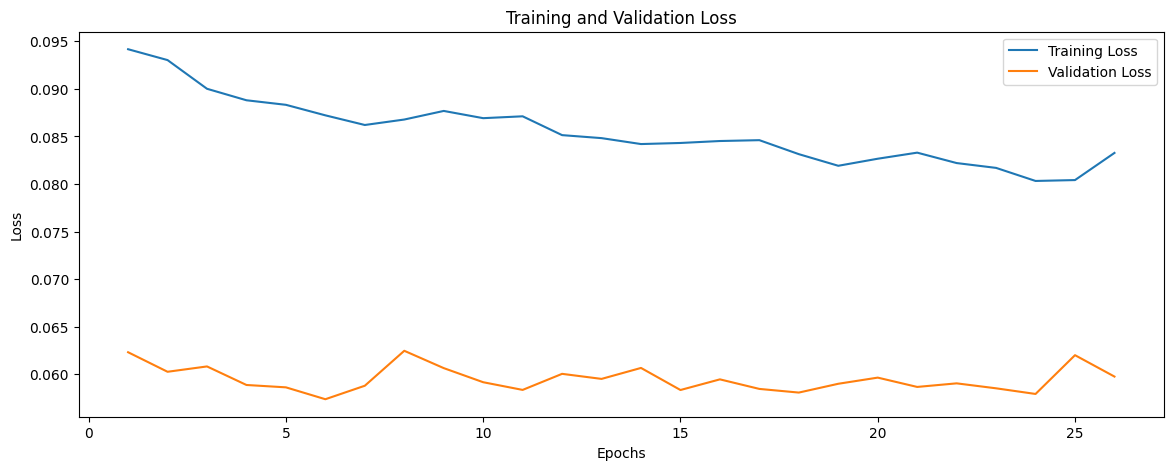

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
from torchvision import transforms
from torchinfo import summary
from scipy.io import loadmat
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import torch.utils.model_zoo as model_zoo
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from functools import partial
import re
import copy
import torchvision.transforms.functional as T

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm
 
def get_data_pts_2d(pts_3d, RT, cam_K):
    pts_2d=np.matmul(pts_3d,RT[:,:3].T)+RT[:,3:].T
    pts_2d=np.matmul(pts_2d,cam_K.T)
    pts_2d=pts_2d[:,:2]/pts_2d[:,2:]
    return pts_2d

def compute_vertex_hcoords(mask, hcoords, use_motion=False):
    h,w=mask.shape
    m=hcoords.shape[0]
    xy = np.argwhere(mask == 1)[:, [1, 0]]
    vertex = xy[:, None, :]*hcoords[None, :, 2:]
    vertex = hcoords[None, :, :2] - vertex
    if not use_motion:
        norm = np.linalg.norm(vertex, axis=2, keepdims=True)
        norm[norm<1e-3] += 1e-3
        vertex = vertex / norm

    vertex_out=np.zeros([h,w,m,2],np.float32)
    vertex_out[xy[:, 1], xy[:, 0]] = vertex
    return  np.reshape(vertex_out,[h,w,m*2])

def smooth_l1_loss(vertex_pred, vertex_targets, vertex_weights, sigma=1.0, normalize=True, reduce=True):
    '''
    :param vertex_pred:     [b,vn*2,h,w]
    :param vertex_targets:  [b,vn*2,h,w]
    :param vertex_weights:  [b,1,h,w]
    :param sigma:
    :param normalize:
    :param reduce:
    :return:
    '''
    b,ver_dim,_,_=vertex_pred.shape
    sigma_2 = sigma ** 2
    vertex_diff = vertex_pred - vertex_targets
    diff = vertex_weights * vertex_diff
    abs_diff = torch.abs(diff)
    smoothL1_sign = (abs_diff < 1. / sigma_2).detach().float()
    in_loss = torch.pow(diff, 2) * (sigma_2 / 2.) * smoothL1_sign \
              + (abs_diff - (0.5 / sigma_2)) * (1. - smoothL1_sign)

    if normalize:
        in_loss=torch.sum(in_loss.view(b,-1),1) / (ver_dim * torch.sum(vertex_weights.view(b,-1),1) + 1e-3)

    if reduce:
       return torch.mean(in_loss)

    return in_loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

def visualize_object_with_bbox(rgb_img, mask, hcoords, figsize=(15, 5)):
    """Visualize RGB, mask, and projected keypoints"""
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title('RGB Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(rgb_img)
    plt.title('Keypoints Projection')
    
    points_2d = hcoords[:, :2].numpy()
    
    segments = {
        'top_square': [(0, 1), (1, 2), (2, 3), (3, 0)],  # Top square
        'vertical': [(0, 4), (1, 5), (2, 6), (3, 7)],     # Vertical connections
        'base_square': [(4, 5), (5, 6), (6, 7), (7, 4)],   # Base square
        'antenna': [(1, 8), (2, 9), (3, 10)]              # Antenna connections
    }
    
    segment_colors = {
        'top_square': 'b',   # Blue
        'vertical': 'g',      # Green
        'base_square': 'c',    # Cyan 
        'antenna': 'm'        # Magenta
    }
    
    for seg_type, connections in segments.items():
        color = segment_colors[seg_type]
        for p1_idx, p2_idx in connections:
            if p1_idx < len(points_2d) and p2_idx < len(points_2d):
                plt.plot([points_2d[p1_idx, 0], points_2d[p2_idx, 0]],
                         [points_2d[p1_idx, 1], points_2d[p2_idx, 1]],
                         f'{color}-', linewidth=1.5, label=seg_type if connections.index((p1_idx, p2_idx)) == 0 else "")
    
    plt.scatter(points_2d[:, 0], points_2d[:, 1], c='r', s=50)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize='small')
    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_vertex(vertex, vertex_weights, keypoints=None):
    """
    Visualize vertex vectors with directional coloring on a black background.
    Also plots the keypoints locations if provided.
    
    Args:
        vertex: Vertex vectors [batch, channels, height, width]
        vertex_weights: Vertex weights [batch, 1, height, width]
        keypoints: Optional keypoints to plot [11, 3] (hcoords)
    """
    
    # Apply weights to vertex
    vertex = vertex * vertex_weights
    
    # Changed to 3x3 grid to accommodate 8 keypoints
    plt.figure(figsize=(15, 15))
    n_keypoints = vertex.shape[1] // 2

    # Create directional images for each keypoint
    for i in range(n_keypoints):
        ax = plt.subplot(4, 3, i+1)
        
        # Get x and y components
        vx = vertex[0, 2*i].cpu().numpy()
        vy = vertex[0, 2*i+1].cpu().numpy()
        
        # Calculate angle and magnitude
        angle = np.arctan2(vy, vx)
        magnitude = np.sqrt(vx**2 + vy**2)
        
        # Create HSV image
        h, w = vx.shape
        hsv_img = np.zeros((h, w, 3))
        
        # Calculate normalized angle (hue), but flip the angle to match the legend
        # This ensures colors in the visualization match the direction legend
        hsv_img[:, :, 0] = ((-angle + 2*np.pi) % (2*np.pi)) / (2*np.pi)  # Hue from angle
        hsv_img[:, :, 1] = 1.0  # Full saturation
        
        # Get mask of valid pixels
        mask = vertex_weights[0, 0].cpu().numpy() > 0
        
        # Set value channel (brightness)
        hsv_img[:, :, 2] = np.zeros_like(magnitude)  # Black background
        if mask.any() and magnitude[mask].max() > 0:
            hsv_img[:, :, 2][mask] = np.clip(magnitude[mask] / magnitude[mask].max(), 0, 1)
        
        # Convert to RGB
        rgb_img = hsv_to_rgb(hsv_img)
        
        plt.imshow(rgb_img)
        
        # Plot keypoint if provided
        if keypoints is not None and i < len(keypoints):
            kp_x, kp_y = int(keypoints[i, 0]), int(keypoints[i, 1])
            if 0 <= kp_x < w and 0 <= kp_y < h:
                plt.scatter(kp_x, kp_y, c='cyan', s=100, marker='*', edgecolors='white')
        
        plt.title(f'Keypoint {i}')
        plt.axis('off')

        # Add inset legend to the bottom right
        ax_inset = ax.inset_axes([0.7, 0.05, 0.25, 0.25])
        
        # Generate a color wheel
        size = 100
        center = size // 2
        y, x = np.ogrid[:size, :size]
        dist = np.sqrt((x - center)**2 + (y - center)**2)
        
        # Create a circular mask
        mask_wheel = dist <= center
        
        # Generate the color wheel
        angles = np.arctan2(center - y, x - center)
        hues = ((angles + 2*np.pi) % (2*np.pi)) / (2*np.pi)
        
        # Create HSV image
        hsv_wheel = np.zeros((size, size, 3))
        hsv_wheel[:, :, 0] = hues
        hsv_wheel[:, :, 1] = 1.0 # Use full saturation for simplicity
        hsv_wheel[:, :, 2] = mask_wheel.astype(float)
        
        # Convert to RGB
        rgb_wheel = hsv_to_rgb(hsv_wheel)
        
        ax_inset.imshow(rgb_wheel)
        ax_inset.axis('off')
        
        # Add direction labels
        directions = ['E', 'N', 'W', 'S']
        angles_text = [0, np.pi/2, np.pi, 3*np.pi/2]
        radius = center * 0.8
        
        for angle_text, direction in zip(angles_text, directions):
            x_t = center + radius * np.cos(angle_text)
            y_t = center - radius * np.sin(angle_text)
            ax_inset.text(x_t, y_t, direction, ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()

class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, mask_dir, transform=None):
        self.transform = transform

        self.rgbPthList = []
        self.maskPthList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.mask_dir = mask_dir    

        self.keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        self.cameraMatrix, self.distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }

            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))
                
                pngFilename = filename.replace('.jpg', '.png')
                
                self.rgbPthList.append(os.path.join(self.images_dir, filename))
                self.maskPthList.append(os.path.join(self.mask_dir, pngFilename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'frame_idx': frame_idx,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>10:
                #     break

    def __len__(self):
        return len(self.rgbPthList)

    def __getitem__(self, idx):
        rgb_path = self.rgbPthList[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_img = np.array(rgb_img)
        rgb = torch.from_numpy(rgb_img).float().permute(2, 0, 1)
        
        mask_path = self.maskPthList[idx]
        mask_img = Image.open(mask_path).convert('1')
        mask_seg = np.array(mask_img).astype(np.int32)
        mask = torch.from_numpy(mask_seg).long()
        
        frame_info = self.frameInfoList[idx]        
        keypts2d = project_keypoints(frame_info['q_vbs2tango'], frame_info['r_Vo2To_vbs'], self.cameraMatrix, self.distCoeffs, self.keypts3d).T # (11, 2)
        hcoords = np.concatenate([keypts2d, np.ones([11, 1], np.float32)], 1)

        rotation_matrix = quat2dcm(frame_info['q_vbs2tango'])
        translation_vector = frame_info['r_Vo2To_vbs'].reshape(3, 1)
        RT = np.hstack((rotation_matrix, translation_vector))

        orig_h, orig_w = mask_seg.shape

        xmin = np.min(keypts2d[:, 0])
        xmax = np.max(keypts2d[:, 0])
        ymin = np.min(keypts2d[:, 1])
        ymax = np.max(keypts2d[:, 1])

        width = xmax - xmin
        height = ymax - ymin
        margin_x = width * 0.05
        margin_y = height * 0.05

        xmin = max(0, xmin - margin_x)
        xmax = min(orig_w, xmax + margin_x)
        ymin = max(0, ymin - margin_y)
        ymax = min(orig_h, ymax + margin_y)

        xmin, xmax, ymin, ymax = map(int, [xmin, xmax, ymin, ymax])

        rgb_cropped = rgb[:, ymin:ymax, xmin:xmax]
        mask_cropped = mask[ymin:ymax, xmin:xmax]

        keypts2d_cropped = keypts2d.copy()
        keypts2d_cropped[:, 0] -= xmin
        keypts2d_cropped[:, 1] -= ymin

        hcoords_cropped = np.concatenate([keypts2d_cropped, np.ones([11, 1], np.float32)], 1)

        rgb_cropped = T.resize(rgb_cropped, [192, 256])
        mask_cropped = T.resize(mask_cropped.unsqueeze(0), [192, 256], interpolation=Image.NEAREST).squeeze(0)

        crop_h, crop_w = ymax - ymin, xmax - xmin
        scale_x = 256 / crop_w
        scale_y = 192 / crop_h

        keypts2d_resized = keypts2d_cropped.copy()
        keypts2d_resized[:, 0] *= scale_x
        keypts2d_resized[:, 1] *= scale_y

        hcoords_resized = hcoords_cropped.copy()
        hcoords_resized[:, 0] *= scale_x
        hcoords_resized[:, 1] *= scale_y

        mask_np = mask_cropped.numpy().astype(np.int32)
        ver_np = compute_vertex_hcoords(mask_np, hcoords_resized, use_motion=False)
        hcoords = torch.tensor(hcoords_resized.astype(np.float32))

        ver = torch.tensor(ver_np, dtype=torch.float32).permute(2, 0, 1)
        ver_weight = mask_cropped.unsqueeze(0).float()
        pose = torch.tensor(RT.astype(np.float32))

        return rgb_cropped, mask_cropped, ver, ver_weight, pose, hcoords

dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', mask_dir= '/kaggle/input/speedsplitmaskssamvit-h/speedsplit/speed/masks/trainval')
train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])

num_images = min(5,len(dataset))
for idx in range(num_images):
    print(f"Visualizing sample {idx}")
    rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[idx]
    rgb_np = rgb_sample.permute(1, 2, 0).numpy().astype(np.uint8)
    mask_np = mask_sample.numpy()
    
    visualize_object_with_bbox(rgb_np, mask_np, hcoords_sample)

rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[0]

ver_sample = ver_sample.unsqueeze(0) 
ver_weight_sample = ver_weight_sample.unsqueeze(0)  

visualize_vertex(ver_sample, ver_weight_sample, hcoords_sample)


class Mlp(nn.Module):
    """ Multilayer perceptron."""

    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def window_partition(x, window_size):
    """
    Args:
        x: (B, H, W, C)
        window_size (int): window size

    Returns:
        windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image

    Returns:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    """ Window based multi-head self attention (W-MSA) module with relative position bias.
    It supports both of shifted and non-shifted window.

    Args:
        dim (int): Number of input channels.
        window_size (tuple[int]): The height and width of the window.
        num_heads (int): Number of attention heads.
        qkv_bias (bool, optional):  If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set
        attn_drop (float, optional): Dropout ratio of attention weight. Default: 0.0
        proj_drop (float, optional): Dropout ratio of output. Default: 0.0
    """

    def __init__(self, dim, window_size, num_heads, qkv_bias=True, qk_scale=None, attn_drop=0., proj_drop=0.):

        super().__init__()
        self.dim = dim
        self.window_size = window_size  # Wh, Ww
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        # define a parameter table of relative position bias
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))  # 2*Wh-1 * 2*Ww-1, nH

        # get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w]))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, Wh*Ww, Wh*Ww
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # Wh*Ww, Wh*Ww, 2
        relative_coords[:, :, 0] += self.window_size[0] - 1  # shift to start from 0
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)  # Wh*Ww, Wh*Ww
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """ Forward function.

        Args:
            x: input features with shape of (num_windows*B, N, C)
            mask: (0/-inf) mask with shape of (num_windows, Wh*Ww, Wh*Ww) or None
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # make torchscript happy (cannot use tensor as tuple)

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)  # Wh*Ww,Wh*Ww,nH
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()  # nH, Wh*Ww, Wh*Ww
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class SwinTransformerBlock(nn.Module):
    """ Swin Transformer Block.

    Args:
        dim (int): Number of input channels.
        num_heads (int): Number of attention heads.
        window_size (int): Window size.
        shift_size (int): Shift size for SW-MSA.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float, optional): Stochastic depth rate. Default: 0.0
        act_layer (nn.Module, optional): Activation layer. Default: nn.GELU
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """

    def __init__(self, dim, num_heads, window_size=7, shift_size=0,
                 mlp_ratio=4., qkv_bias=True, qk_scale=None, drop=0., attn_drop=0., drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        assert 0 <= self.shift_size < self.window_size, "shift_size must in 0-window_size"

        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(
            dim, window_size=to_2tuple(self.window_size), num_heads=num_heads,
            qkv_bias=qkv_bias, qk_scale=qk_scale, attn_drop=attn_drop, proj_drop=drop)

        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        self.H = None
        self.W = None

    def forward(self, x, mask_matrix):
        """ Forward function.

        Args:
            x: Input feature, tensor size (B, H*W, C).
            H, W: Spatial resolution of the input feature.
            mask_matrix: Attention mask for cyclic shift.
        """
        B, L, C = x.shape
        H, W = self.H, self.W
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # pad feature maps to multiples of window size
        pad_l = pad_t = 0
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, pad_l, pad_r, pad_t, pad_b))
        _, Hp, Wp, _ = x.shape

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
            attn_mask = mask_matrix
        else:
            shifted_x = x
            attn_mask = None

        # partition windows
        x_windows = window_partition(shifted_x, self.window_size)  # nW*B, window_size, window_size, C
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(x_windows, mask=attn_mask)  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, Hp, Wp)  # B H' W' C

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x

        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = x.view(B, H * W, C)

        # FFN
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x


class PatchMerging(nn.Module):
    """ Patch Merging Layer

    Args:
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """
    def __init__(self, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x, H, W):
        """ Forward function.

        Args:
            x: Input feature, tensor size (B, H*W, C).
            H, W: Spatial resolution of the input feature.
        """
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        x = x.view(B, H, W, C)

        # padding
        pad_input = (H % 2 == 1) or (W % 2 == 1)
        if pad_input:
            x = F.pad(x, (0, 0, 0, W % 2, 0, H % 2))

        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x


class BasicLayer(nn.Module):
    """ A basic Swin Transformer layer for one stage.

    Args:
        dim (int): Number of feature channels
        depth (int): Depths of this stage.
        num_heads (int): Number of attention head.
        window_size (int): Local window size. Default: 7.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
    """

    def __init__(self,
                 dim,
                 depth,
                 num_heads,
                 window_size=7,
                 mlp_ratio=4.,
                 qkv_bias=True,
                 qk_scale=None,
                 drop=0.,
                 attn_drop=0.,
                 drop_path=0.,
                 norm_layer=nn.LayerNorm,
                 downsample=None,
                 use_checkpoint=False):
        super().__init__()
        self.window_size = window_size
        self.shift_size = window_size // 2
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        # build blocks
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                norm_layer=norm_layer)
            for i in range(depth)])

        # patch merging layer
        if downsample is not None:
            self.downsample = downsample(dim=dim, norm_layer=norm_layer)
        else:
            self.downsample = None

    def forward(self, x, H, W):
        """ Forward function.

        Args:
            x: Input feature, tensor size (B, H*W, C).
            H, W: Spatial resolution of the input feature.
        """

        # calculate attention mask for SW-MSA
        Hp = int(np.ceil(H / self.window_size)) * self.window_size
        Wp = int(np.ceil(W / self.window_size)) * self.window_size
        img_mask = torch.zeros((1, Hp, Wp, 1), device=x.device)  # 1 Hp Wp 1
        h_slices = (slice(0, -self.window_size),
                    slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        w_slices = (slice(0, -self.window_size),
                    slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        cnt = 0
        for h in h_slices:
            for w in w_slices:
                img_mask[:, h, w, :] = cnt
                cnt += 1

        mask_windows = window_partition(img_mask, self.window_size)  # nW, window_size, window_size, 1
        mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))

        for blk in self.blocks:
            blk.H, blk.W = H, W
            x = blk(x, attn_mask)
        if self.downsample is not None:
            x_down = self.downsample(x, H, W)
            Wh, Ww = (H + 1) // 2, (W + 1) // 2
            return x, H, W, x_down, Wh, Ww
        else:
            return x, H, W, x, H, W

class PatchEmbed(nn.Module):
    """ Image to Patch Embedding

    Args:
        patch_size (int): Patch token size. Default: 4.
        in_chans (int): Number of input image channels. Default: 3.
        embed_dim (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """

    def __init__(self, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None):
        super().__init__()
        patch_size = to_2tuple(patch_size)
        self.patch_size = patch_size

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        if norm_layer is not None:
            self.norm = norm_layer(embed_dim)
        else:
            self.norm = None

    def forward(self, x):
        """Forward function."""
        # padding
        _, _, H, W = x.size()
        if W % self.patch_size[1] != 0:
            x = F.pad(x, (0, self.patch_size[1] - W % self.patch_size[1]))
        if H % self.patch_size[0] != 0:
            x = F.pad(x, (0, 0, 0, self.patch_size[0] - H % self.patch_size[0]))

        x = self.proj(x)  # B C Wh Ww
        if self.norm is not None:
            Wh, Ww = x.size(2), x.size(3)
            x = x.flatten(2).transpose(1, 2)
            x = self.norm(x)
            x = x.transpose(1, 2).view(-1, self.embed_dim, Wh, Ww)

        return x

class SwinTransformer(nn.Module):
    """ Swin Transformer backbone.
        A PyTorch impl of : `Swin Transformer: Hierarchical Vision Transformer using Shifted Windows`  -
          https://arxiv.org/pdf/2103.14030

    Args:
        pretrain_img_size (int): Input image size for training the pretrained model,
            used in absolute postion embedding. Default 224.
        patch_size (int | tuple(int)): Patch size. Default: 4.
        in_chans (int): Number of input image channels. Default: 3.
        embed_dim (int): Number of linear projection output channels. Default: 96.
        depths (tuple[int]): Depths of each Swin Transformer stage.
        num_heads (tuple[int]): Number of attention head of each stage.
        window_size (int): Window size. Default: 7.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.
        qkv_bias (bool): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float): Override default qk scale of head_dim ** -0.5 if set.
        drop_rate (float): Dropout rate.
        attn_drop_rate (float): Attention dropout rate. Default: 0.
        drop_path_rate (float): Stochastic depth rate. Default: 0.2.
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
        ape (bool): If True, add absolute position embedding to the patch embedding. Default: False.
        patch_norm (bool): If True, add normalization after patch embedding. Default: True.
        out_indices (Sequence[int]): Output from which stages.
        frozen_stages (int): Stages to be frozen (stop grad and set eval mode).
            -1 means not freezing any parameters.
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
    """

    def __init__(self,
                 pretrain_img_size=224,
                 patch_size=4,
                 in_chans=3,
                 embed_dim=96,
                 depths=[2, 2, 6, 2],
                 num_heads=[3, 6, 12, 24],
                 window_size=7,
                 mlp_ratio=4.,
                 qkv_bias=True,
                 qk_scale=None,
                 drop_rate=0.,
                 attn_drop_rate=0.,
                 drop_path_rate=0.2,
                 norm_layer=nn.LayerNorm,
                 ape=False,
                 patch_norm=True,
                 out_indices=(0, 1, 2, 3),
                 frozen_stages=-1,
                 use_checkpoint=False):
        super().__init__()

        self.pretrain_img_size = pretrain_img_size
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.ape = ape
        self.patch_norm = patch_norm
        self.out_indices = out_indices
        self.frozen_stages = frozen_stages

        # split image into non-overlapping patches
        self.patch_embed = PatchEmbed(
            patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None)

        # absolute position embedding
        if self.ape:
            pretrain_img_size = to_2tuple(pretrain_img_size)
            patch_size = to_2tuple(patch_size)
            patches_resolution = [pretrain_img_size[0] // patch_size[0], pretrain_img_size[1] // patch_size[1]]

            self.absolute_pos_embed = nn.Parameter(torch.zeros(1, embed_dim, patches_resolution[0], patches_resolution[1]))
            trunc_normal_(self.absolute_pos_embed, std=.02)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]  # stochastic depth decay rule

        # build layers
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]):sum(depths[:i_layer + 1])],
                norm_layer=norm_layer,
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None,
                use_checkpoint=use_checkpoint)
            self.layers.append(layer)

        num_features = [int(embed_dim * 2 ** i) for i in range(self.num_layers)]
        self.num_features = num_features

        # add a norm layer for each output
        for i_layer in out_indices:
            layer = norm_layer(num_features[i_layer])
            layer_name = f'norm{i_layer}'
            self.add_module(layer_name, layer)

        self._freeze_stages()

    def _freeze_stages(self):
        if self.frozen_stages >= 0:
            self.patch_embed.eval()
            for param in self.patch_embed.parameters():
                param.requires_grad = False

        if self.frozen_stages >= 1 and self.ape:
            self.absolute_pos_embed.requires_grad = False

        if self.frozen_stages >= 2:
            self.pos_drop.eval()
            for i in range(0, self.frozen_stages - 1):
                m = self.layers[i]
                m.eval()
                for param in m.parameters():
                    param.requires_grad = False

    def init_weights(self, pretrained=None):
        """Initialize the weights in backbone.

        Args:
            pretrained (str, optional): Path to pre-trained weights.
                Defaults to None.
        """

        def _init_weights(m):
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=.02)
                if isinstance(m, nn.Linear) and m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.bias, 0)
                nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        """Forward function."""
        x = self.patch_embed(x)

        Wh, Ww = x.size(2), x.size(3)
        if self.ape:
            # interpolate the position embedding to the corresponding size
            absolute_pos_embed = F.interpolate(self.absolute_pos_embed, size=(Wh, Ww), mode='bicubic')
            x = (x + absolute_pos_embed).flatten(2).transpose(1, 2)  # B Wh*Ww C
        else:
            x = x.flatten(2).transpose(1, 2)
        x = self.pos_drop(x)

        outs = []
        for i in range(self.num_layers):
            layer = self.layers[i]
            x_out, H, W, x, Wh, Ww = layer(x, Wh, Ww)

            if i in self.out_indices:
                norm_layer = getattr(self, f'norm{i}')
                x_out = norm_layer(x_out)

                out = x_out.view(-1, H, W, self.num_features[i]).permute(0, 3, 1, 2).contiguous()
                outs.append(out)

        return tuple(outs)

class SwimPVNet(nn.Module):
    def __init__(self, ver_dim, seg_dim, pretrained_mae_path=None):
        super(SwimPVNet, self).__init__()
        self.ver_dim = ver_dim
        self.seg_dim = seg_dim

        self.swin = SwinTransformer(
            pretrain_img_size=(256, 192),
            patch_size=4,
            in_chans=3,
            embed_dim=96,
            depths=[2, 2, 6, 2],
            num_heads=[3, 6, 12, 24],
            window_size=7,
            mlp_ratio=4.,
            qkv_bias=True,
            qk_scale=None,
            drop_rate=0.,
            attn_drop_rate=0.,
            drop_path_rate=0.2,
            norm_layer=nn.LayerNorm,
            ape=False,
            patch_norm=True,
            out_indices=(0, 1, 2, 3),
            frozen_stages=-1,
            use_checkpoint=False
        )

        self.conv8s = nn.Sequential(
            nn.Conv2d(768+384, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, True),
            nn.Dropout2d(0.1)
        )
        self.up8sto4s = nn.UpsamplingBilinear2d(scale_factor=2)

        self.conv4s = nn.Sequential(
            nn.Conv2d(128+192, 64, 3, 1, 1, bias=False),  # Skip connection
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, True),
            nn.Dropout2d(0.1)
        )
        self.up4sto2s = nn.UpsamplingBilinear2d(scale_factor=2)

        self.conv2s = nn.Sequential(
            nn.Conv2d(64+96, 32, 3, 1, 1, bias=False),   # Skip connection
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, True),
            nn.Dropout2d(0.1)
        )
        self.up2storaw = nn.UpsamplingBilinear2d(scale_factor=2)

        self.convraw = nn.Sequential(
            nn.Conv2d(32+3, 32, 3, 1, 1, bias=False),   # Skip connection
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, True),
            nn.Dropout2d(0.1),
            nn.Conv2d(32, seg_dim + ver_dim, 1, 1)
        )
        
        # Initialize decoder weights
        self._initialize_decoder()

    def _initialize_decoder(self):
        for m in [self.conv8s, self.conv4s, self.conv2s, self.convraw]:
            for layer in m.modules():
                if isinstance(layer, nn.Conv2d):
                    nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='leaky_relu')
                elif isinstance(layer, nn.BatchNorm2d):
                    nn.init.constant_(layer.weight, 1)
                    nn.init.constant_(layer.bias, 0)

    def upsample_features(self, features):
        """Upsample features from multiple SWIM Stages"""
        f1 = F.interpolate(features[0], scale_factor=2, mode='bilinear', align_corners=False)
        f2 = F.interpolate(features[1], scale_factor=2, mode='bilinear', align_corners=False)
        f3 = F.interpolate(features[2], scale_factor=2, mode='bilinear', align_corners=False)
        f4 = F.interpolate(features[3], scale_factor=4, mode='bilinear', align_corners=False)
        return [f1, f2, f3, f4]

    def forward(self, x):
        # Extract multi-scale features
        x_feats = self.swin(x) 
        # print(f"x_feats shape: {x_feats[0].shape}, {x_feats[1].shape}, {x_feats[2].shape}, {x_feats[3].shape}")

        features = self.upsample_features(x_feats)
        # print(f"Upsampled features shape: {features[0].shape}, {features[1].shape}, {features[2].shape}, {features[3].shape}")

        x2s = features[0]  #96x128
        x4s = features[1]  #48x64
        x8s = features[2]  #24x32
        xfc = features[3]  #24x32

        # print(f"Before concat xfc: {xfc.shape}, x8s: {x8s.shape}")
        fm = self.conv8s(torch.cat([xfc, x8s], 1))  # 768+384
        fm = self.up8sto4s(fm)    

        # print(f"Before concat fm: {fm.shape}, x4s: {x4s.shape}")
        fm = self.conv4s(torch.cat([fm, x4s], 1))   # 128 + 192
        fm = self.up4sto2s(fm)    

        # print(f"Before concat fm: {fm.shape}, x2s: {x2s.shape}")
        fm = self.conv2s(torch.cat([fm, x2s], 1))   # 64 + 96
        fm = self.up2storaw(fm)

        # print(f"Before concat fm: {fm.shape}, x: {x.shape}")
        final_out = self.convraw(torch.cat([fm, x], 1))  # 32 + 3
          
        seg_pred = final_out[:, :self.seg_dim, :, :]
        ver_pred = final_out[:, self.seg_dim:, :, :]        

        return seg_pred, ver_pred


def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X, yMask, yVer, yVerWeight, yPose, yHcoords ) in enumerate(train_dataloader):
        X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
        model.train()
        optimizer.zero_grad()

        with autocast("cuda"):
            seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0],-1),1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver)

        scaler.scale(loss).backward()
        
        # Apply gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=norm_type)
        
        scaler.step(optimizer)
        scaler.update()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")

    # scheduler.step()  
    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, yMask, yVer, yVerWeight, yPose, yHcoords) in enumerate(val_dataloader):
            X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
            with autocast("cuda"):
                seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0], -1), 1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver).item()
            val_loss += loss
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {loss:>7f}  [{batch * batch_size + len(X):>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {val_loss:>7f}                                         ")
    print(end='')
    return loss_avg, val_loss


class LayerDecayOptimizerConstructor:
    def __init__(self, optimizer_type, lr, betas, weight_decay, paramwise_cfg):
        self.optimizer_type = optimizer_type
        self.lr = lr
        self.betas = betas
        self.weight_decay = weight_decay
        self.paramwise_cfg = paramwise_cfg
    
    def __call__(self, model):
        parameter_groups = []
        
        # Get layer decay parameters
        num_layers = self.paramwise_cfg.get('num_layers', 12)
        layer_decay_rate = self.paramwise_cfg.get('layer_decay_rate', 0.8)
        custom_keys = self.paramwise_cfg.get('custom_keys', {})
        
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
                
            if 'vit.patch_embed' in name or 'vit.pos_embed' in name:
                layer_id = 0
            elif 'vit.blocks' in name:
                block_id = int(name.split('vit.blocks.')[1].split('.')[0])
                layer_id = block_id + 1
            elif 'decoder' in name:
                layer_id = num_layers - 1
            else:
                layer_id = 0
                
            lr_scale = layer_decay_rate ** (num_layers - 1 - layer_id)
            
            weight_decay_value = self.weight_decay
            for key, cfg in custom_keys.items():
                if key in name:
                    if 'decay_mult' in cfg:
                        weight_decay_value = self.weight_decay * cfg['decay_mult']
                    break
            
            group = {
                'params': [param],
                'lr': self.lr * lr_scale,
                'weight_decay': weight_decay_value,
                'betas': self.betas
            }
            parameter_groups.append(group)
            
        if self.optimizer_type == 'AdamW':
            return optim.AdamW(parameter_groups)
        else:
            return optim.Adam(parameter_groups)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = SwimPVNet(ver_dim=11 * 2, seg_dim=2,pretrained_mae_path="").to(device)
model.load_state_dict(torch.load('/kaggle/input/swimpvnet/epoch_30_model_weights.pth', map_location=device))

optimizer_cfg = dict(
    type='AdamW', 
    lr=1e-3, 
    betas=(0.9, 0.999), 
    weight_decay=0.1
)

paramwise_cfg = dict(
    num_layers=12,
    layer_decay_rate=0.8,
    custom_keys={
        'bias': dict(decay_mult=0.),
        'pos_embed': dict(decay_mult=0.),
        'relative_position_bias_table': dict(decay_mult=0.),
        'norm': dict(decay_mult=0.)
    }
)

optimizer_constructor = LayerDecayOptimizerConstructor(
    optimizer_cfg['type'], 
    optimizer_cfg['lr'], 
    optimizer_cfg['betas'], 
    optimizer_cfg['weight_decay'],
    paramwise_cfg
)
optimizer = optimizer_constructor(model)

max_norm = 1.0
norm_type = 2

batch_size = 32
epochs = 50
loss_fn = nn.CrossEntropyLoss(reduce=False)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)

# Print model summary
# print(summary(model, (1,3,192,256)))

loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')
patience = 20  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

for t in range(epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    else:
        patience_counter += 1 
    
    if (t + 1) % 5 == 0:
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')
        
    if patience_counter >= patience:
        print(f"\nStopping early at epoch {t+1} with restoring best weights")
        epochs = t+1
        break

plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()